<a href="https://colab.research.google.com/github/sehajd77/MGNM801-TCS-Stock-Analytics/blob/main/TCS_Stock_Price_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install yfinance

In [1]:
# Download 5 years of daily TCS stock data

import yfinance as yf
import pandas as pd

data = yf.download(
    "TCS.NS",
    period="5y",
    interval="1d",
    auto_adjust=False
)

print("Data downloaded successfully!")
print("Number of rows:", len(data))
print("Number of columns:", len(data.columns))

data.head()

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!
Number of rows: 1240
Number of columns: 6


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,,
2021-09-13,3340.449707,3845.350098,3852.399902,3767.000000,3767.000000,1691473
2021-09-14,3375.675293,3885.899902,3896.500000,3825.000000,3849.949951,1991188
2021-09-15,3435.311768,3954.550049,3980.000000,3866.000000,3882.100098,2461369
2021-09-16,3390.790771,3903.300049,3981.750000,3892.100098,3930.000000,2946666
2021-09-17,3325.247314,3827.850098,3945.000000,3805.000000,3920.000000,6477148


In [3]:
# Basic examination of the dataset

print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

print("\nLast 5 Records:")
display(data.tail())

Dataset Shape: (1240, 6)

Column Names:
MultiIndex([('Adj Close', 'TCS.NS'),
            (    'Close', 'TCS.NS'),
            (     'High', 'TCS.NS'),
            (      'Low', 'TCS.NS'),
            (     'Open', 'TCS.NS'),
            (   'Volume', 'TCS.NS')],
           names=['Price', 'Ticker'])

Data Types:
Price      Ticker
Adj Close  TCS.NS    float64
Close      TCS.NS    float64
High       TCS.NS    float64
Low        TCS.NS    float64
Open       TCS.NS    float64
Volume     TCS.NS      int64
dtype: object

Missing Values:
Price      Ticker
Adj Close  TCS.NS    0
Close      TCS.NS    0
High       TCS.NS    0
Low        TCS.NS    0
Open       TCS.NS    0
Volume     TCS.NS    0
dtype: int64

Duplicate Rows:
0

Last 5 Records:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,,
2026-09-04,2304.000000,2304.000000,2363.899902,2302.399902,2330.000000,2564322
2026-09-07,2270.000000,2270.000000,2299.899902,2260.100098,2290.100098,2297551
2026-09-08,2255.500000,2255.500000,2274.500000,2244.000000,2270.000000,2148114
2026-09-09,2208.000000,2208.000000,2237.000000,2193.199951,2237.000000,3370071
2026-09-10,2204.100098,2204.100098,2232.000000,2190.600098,2199.000000,2490349


In [4]:
# Step 3: Data Cleaning

# Flatten the multi-level column names created by yfinance
data.columns = data.columns.get_level_values(0)

# Make sure the Date index is in proper datetime format
data.index = pd.to_datetime(data.index)
data.index.name = "Date"

# Remove today's potentially incomplete trading data
today = pd.Timestamp.today().normalize()
data = data[data.index < today]

# Remove any duplicate rows
data = data[~data.index.duplicated(keep="first")]

# Remove rows with missing values
data = data.dropna()

# Display cleaned dataset information
print("Cleaned Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nMissing Values After Cleaning:")
print(data.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(data.duplicated().sum())

print("\nDate Range:")
print("Start Date:", data.index.min().date())
print("End Date:", data.index.max().date())

print("\nCleaned Dataset:")
display(data.head())

Cleaned Dataset Shape: (1239, 6)

Column Names:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Missing Values After Cleaning:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate Rows After Cleaning:
0

Date Range:
Start Date: 2021-09-13
End Date: 2026-09-09

Cleaned Dataset:


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-09-13,3340.449707,3845.350098,3852.399902,3767.000000,3767.000000,1691473
2021-09-14,3375.675293,3885.899902,3896.500000,3825.000000,3849.949951,1991188
2021-09-15,3435.311768,3954.550049,3980.000000,3866.000000,3882.100098,2461369
2021-09-16,3390.790771,3903.300049,3981.750000,3892.100098,3930.000000,2946666
2021-09-17,3325.247314,3827.850098,3945.000000,3805.000000,3920.000000,6477148


In [5]:
# Step 4: Feature Engineering

# Daily percentage return
data["Daily_Return"] = data["Close"].pct_change() * 100

# 7-day moving average
data["MA_7"] = data["Close"].rolling(window=7).mean()

# 21-day moving average
data["MA_21"] = data["Close"].rolling(window=21).mean()

# 21-day rolling volatility
data["Volatility_21"] = data["Daily_Return"].rolling(window=21).std()

# Previous day's closing price
data["Previous_Close"] = data["Close"].shift(1)

# Next day's closing price - our prediction target
data["Next_Day_Close"] = data["Close"].shift(-1)

# Remove rows created with missing values from calculations
data = data.dropna()

print("Dataset after Feature Engineering:", data.shape)

print("\nNew Variables:")
print(data.columns.tolist())

print("\nFirst 5 records with new features:")
display(data.head())

Dataset after Feature Engineering: (1217, 12)

New Variables:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA_7', 'MA_21', 'Volatility_21', 'Previous_Close', 'Next_Day_Close']

First 5 records with new features:


Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_21,Volatility_21,Previous_Close,Next_Day_Close
Date,,,,,,,,,,,,
2021-10-12,3173.225342,3652.850098,3707.000000,3630.600098,3706.000000,5752877,-0.888593,3797.785714,3826.619036,1.811980,3685.600098,3655.199951
2021-10-13,3175.267090,3655.199951,3675.449951,3645.000000,3650.000000,3545655,0.064329,3780.914272,3815.633324,1.789676,3652.850098,3611.449951
2021-10-14,3143.280762,3611.449951,3670.000000,3608.199951,3625.000000,6442299,-1.196925,3749.221401,3799.295224,1.736662,3655.199951,3647.149902
2021-10-18,3174.353027,3647.149902,3652.699951,3601.449951,3603.449951,3590107,0.988521,3725.828544,3787.097598,1.750315,3611.449951,3634.149902
2021-10-19,3163.038330,3634.149902,3690.100098,3625.199951,3669.000000,3135441,-0.356443,3688.864258,3777.873779,1.710477,3647.149902,3608.850098


In [6]:
# Step 5: Descriptive Analytics

# Summary statistics
print("Summary Statistics:")
display(data.describe().round(2))

# Key statistics for important variables
print("\nKey Statistics:")

print("Average Closing Price:",
      round(data["Close"].mean(), 2))

print("Minimum Closing Price:",
      round(data["Close"].min(), 2))

print("Maximum Closing Price:",
      round(data["Close"].max(), 2))

print("Average Daily Return:",
      round(data["Daily_Return"].mean(), 2), "%")

print("Average Trading Volume:",
      round(data["Volume"].mean(), 0))

print("Average 21-Day Volatility:",
      round(data["Volatility_21"].mean(), 2), "%")

Summary Statistics:


Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_21,Volatility_21,Previous_Close,Next_Day_Close
count,1217.00,1217.00,1217.00,1217.00,1217.00,1217.00,1217.00,1217.00,1217.00,1217.00,1217.00,1217.00
mean,3144.87,3413.07,3444.85,3383.36,3415.25,2599131.54,-0.03,3416.84,3425.48,1.36,3414.24,3411.88
std,465.94,534.46,538.39,530.52,533.68,1629968.60,1.41,529.48,518.95,0.40,533.49,535.53
min,1971.79,1982.60,2052.00,1976.80,2008.00,0.00,-8.39,2055.27,2102.99,0.65,1982.60,1982.60
25%,2900.19,3162.90,3183.50,3138.10,3165.00,1636819.00,-0.77,3165.48,3187.88,1.05,3163.25,3162.50
50%,3094.30,3408.65,3434.90,3382.15,3408.00,2177001.00,-0.05,3413.31,3422.84,1.26,3410.15,3408.35
75%,3408.26,3783.20,3815.95,3746.10,3778.05,3041609.00,0.70,3769.69,3787.10,1.60,3783.20,3783.20
max,4230.71,4553.75,4592.25,4512.00,4576.00,16331582.00,6.63,4514.94,4502.53,2.84,4553.75,4553.75



Key Statistics:
Average Closing Price: 3413.07
Minimum Closing Price: 1982.6
Maximum Closing Price: 4553.75
Average Daily Return: -0.03 %
Average Trading Volume: 2599132.0
Average 21-Day Volatility: 1.36 %


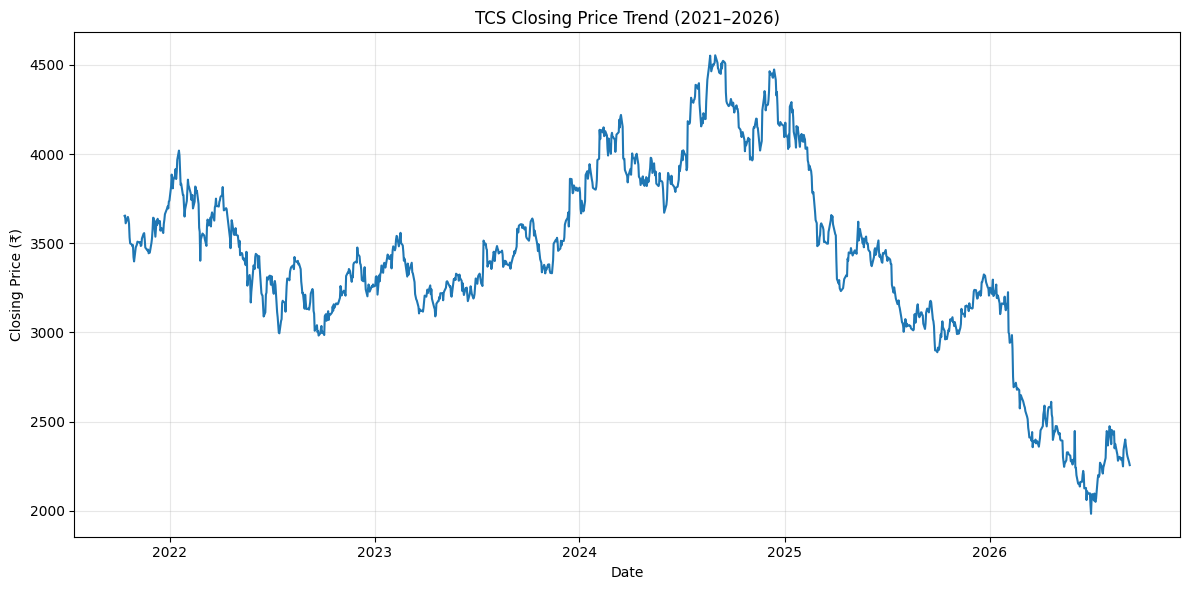

In [7]:
# Visualization 1: TCS Closing Price Trend

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Close"])

plt.title("TCS Closing Price Trend (2021–2026)")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

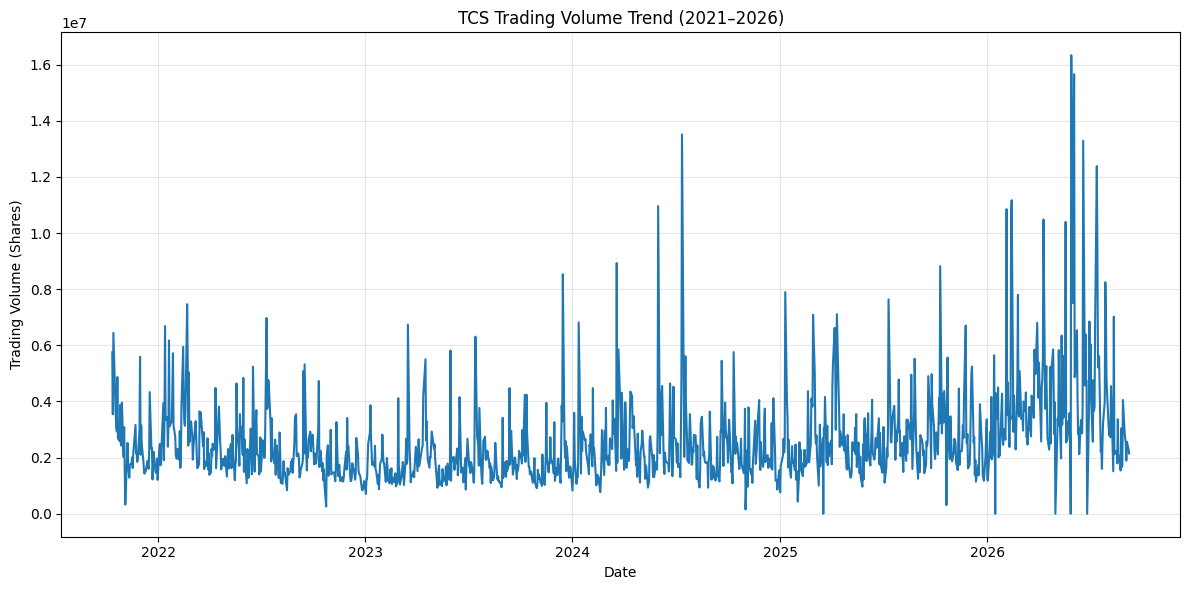

In [8]:
# Visualization 2: TCS Trading Volume Trend

plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Volume"])

plt.title("TCS Trading Volume Trend (2021–2026)")
plt.xlabel("Date")
plt.ylabel("Trading Volume (Shares)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

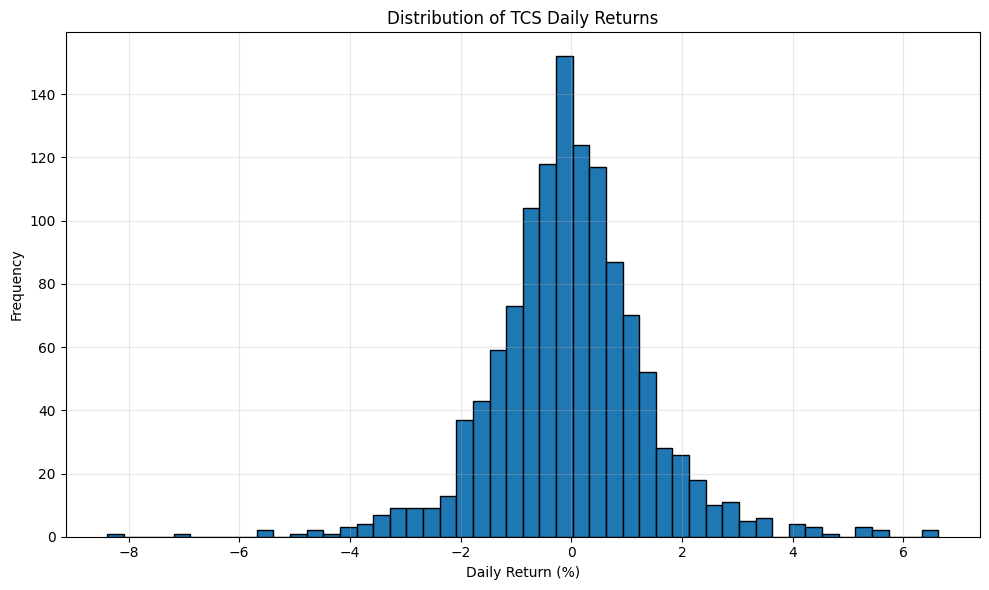

In [9]:
# Visualization 3: Distribution of Daily Returns

plt.figure(figsize=(10, 6))

plt.hist(data["Daily_Return"], bins=50, edgecolor="black")

plt.title("Distribution of TCS Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

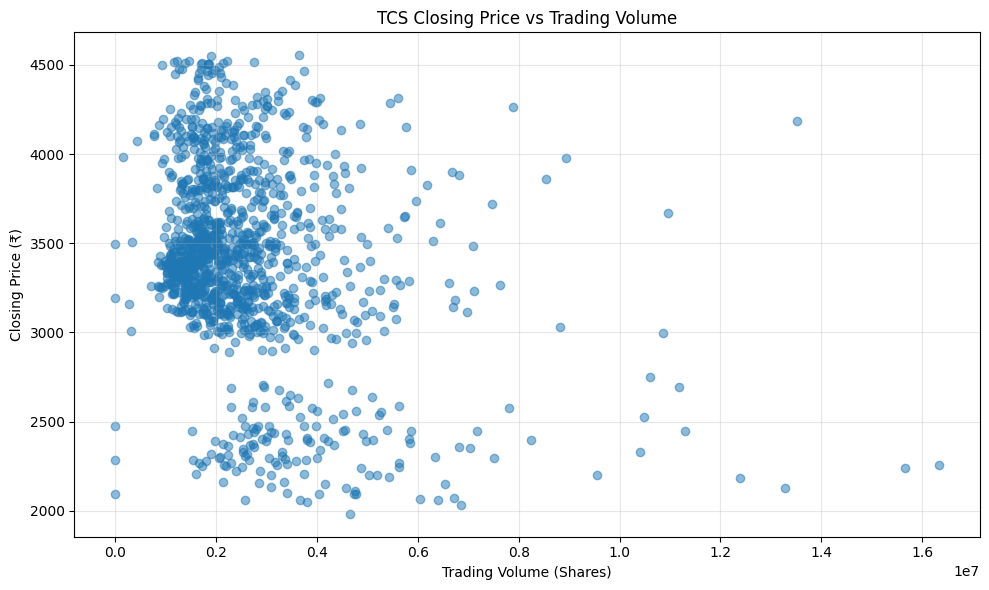

In [10]:
# Visualization 4: Closing Price vs Trading Volume

plt.figure(figsize=(10, 6))

plt.scatter(
    data["Volume"],
    data["Close"],
    alpha=0.5
)

plt.title("TCS Closing Price vs Trading Volume")
plt.xlabel("Trading Volume (Shares)")
plt.ylabel("Closing Price (₹)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Correlation between Closing Price and Trading Volume

correlation = data["Close"].corr(data["Volume"])

print("Correlation between Closing Price and Trading Volume:",
      round(correlation, 3))

Correlation between Closing Price and Trading Volume: -0.29


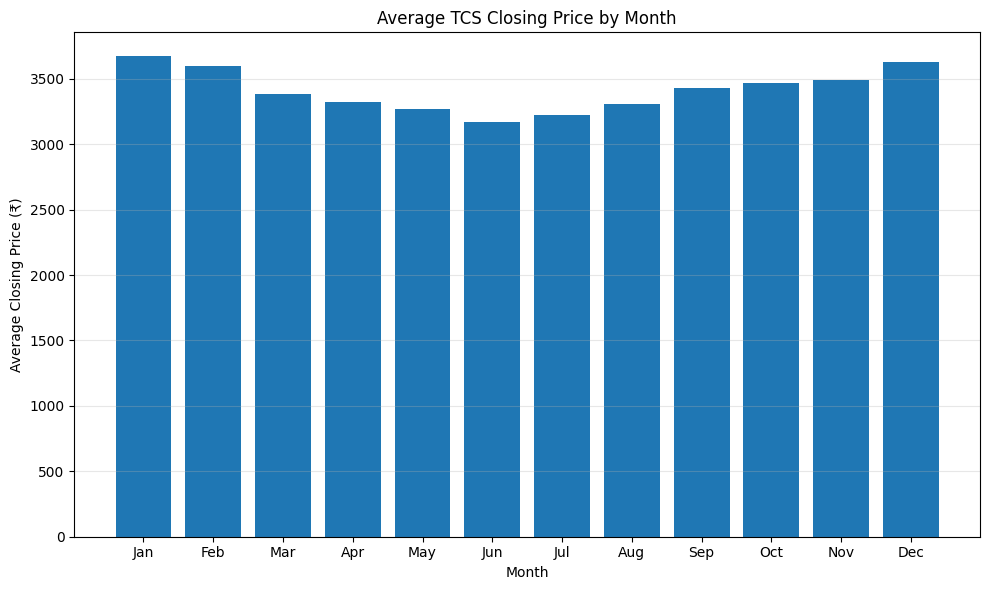

In [12]:
# Visualization 5: Monthly Average Closing Price

monthly_avg = data.groupby(data.index.month)["Close"].mean()

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 6))

plt.bar(month_names, monthly_avg)

plt.title("Average TCS Closing Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Closing Price (₹)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

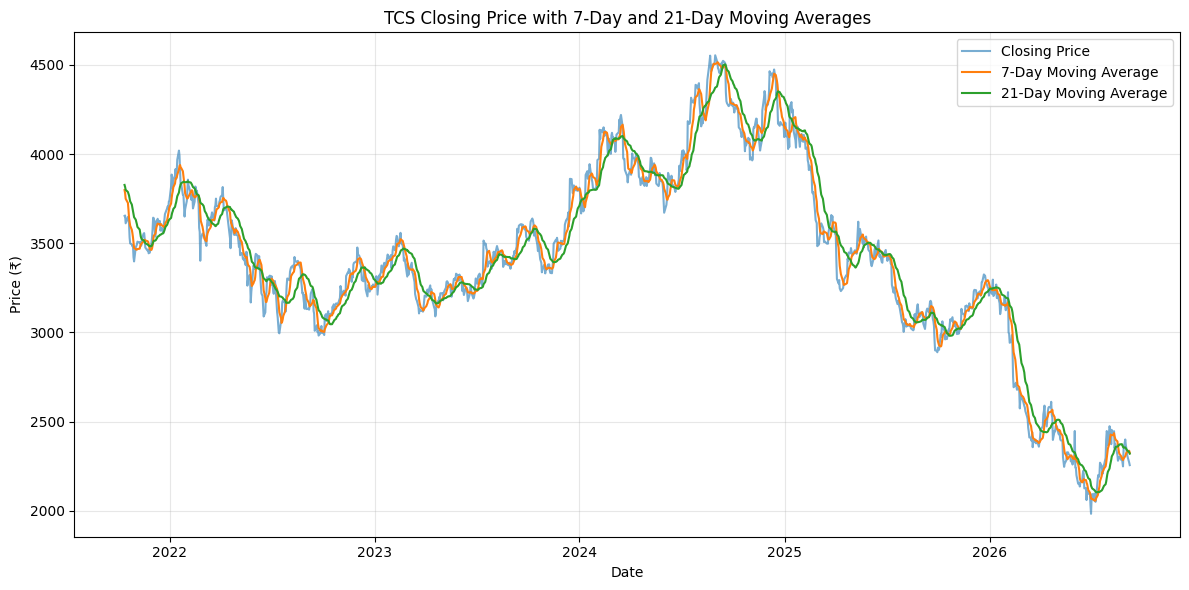

In [13]:
# Visualization 6: Closing Price with Moving Averages

plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Close"], label="Closing Price", alpha=0.6)
plt.plot(data.index, data["MA_7"], label="7-Day Moving Average")
plt.plot(data.index, data["MA_21"], label="21-Day Moving Average")

plt.title("TCS Closing Price with 7-Day and 21-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

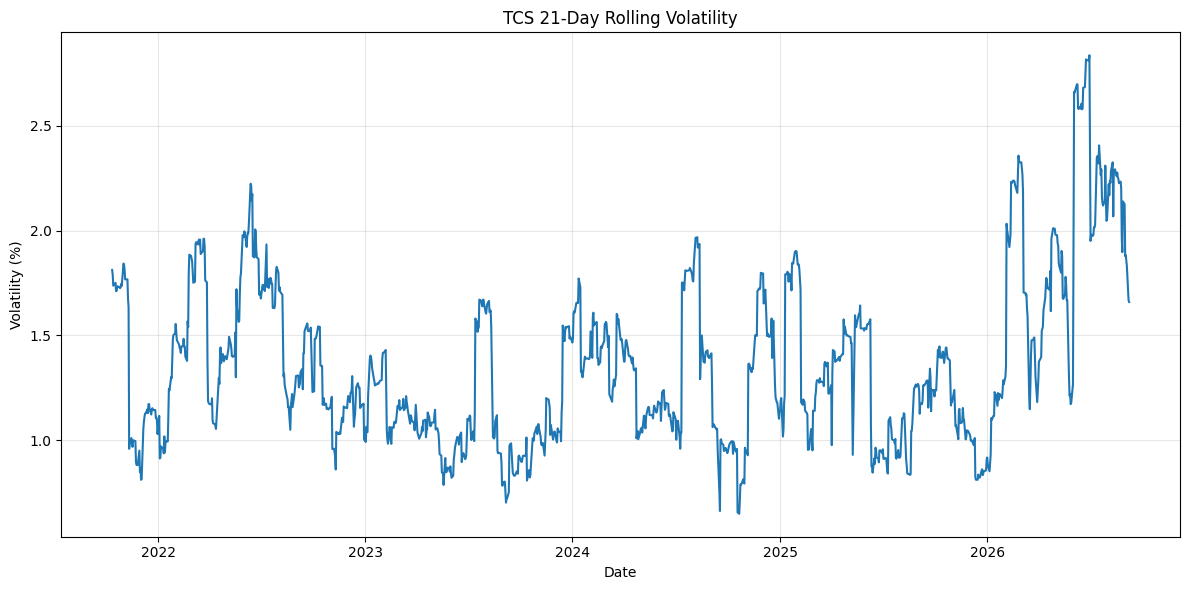

In [14]:
# Visualization 7: 21-Day Rolling Volatility

plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Volatility_21"])

plt.title("TCS 21-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Step 8: Prepare Data for Predictive Modeling

from sklearn.model_selection import train_test_split

# Define predictor variables
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "MA_7",
    "MA_21",
    "Volatility_21",
    "Previous_Close"
]

X = data[features]
y = data["Next_Day_Close"]

# Time-based split: first 80% for training, last 20% for testing
split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTarget Variable:")
print("Next_Day_Close")

print("\nPredictor Variables:")
print(features)

Training observations: 973
Testing observations: 244

Target Variable:
Next_Day_Close

Predictor Variables:
['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'MA_7', 'MA_21', 'Volatility_21', 'Previous_Close']


In [16]:
# Step 9: Random Forest Regression Model

from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

print("Model training completed successfully!")
print("Number of predictions:", len(y_pred))

Model training completed successfully!
Number of predictions: 244


In [17]:
# Step 10: Evaluate the Random Forest Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Evaluation Results
------------------------
MAE : 444.01
RMSE: 568.59
R²  : -1.0131


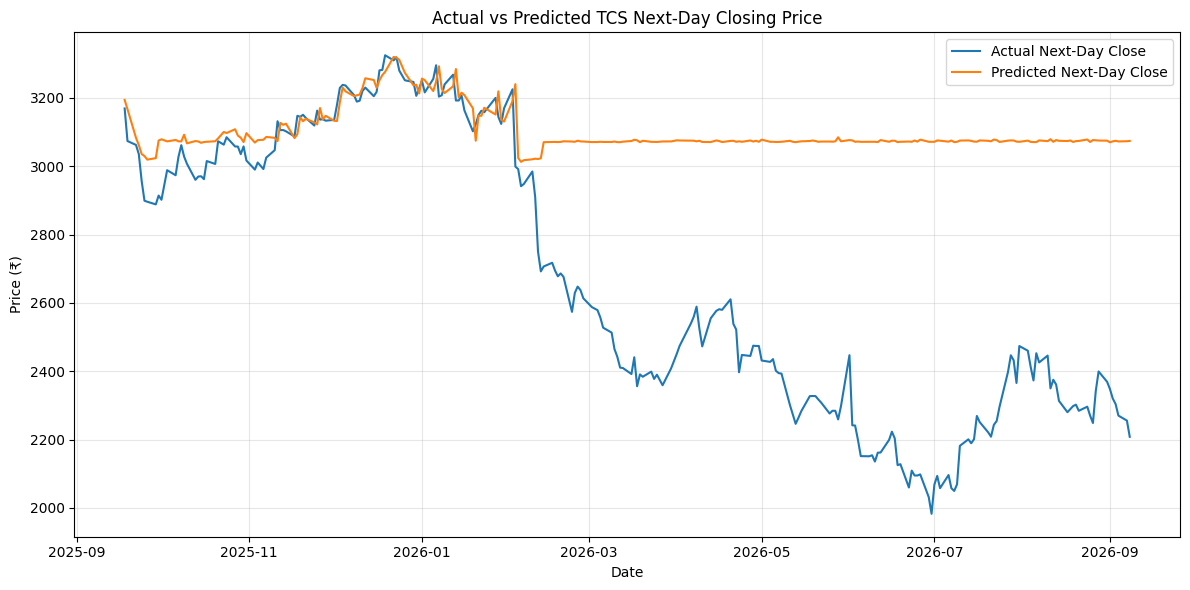

In [18]:
# Step 11: Actual vs Predicted Closing Prices

plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test.values, label="Actual Next-Day Close")
plt.plot(y_test.index, y_pred, label="Predicted Next-Day Close")

plt.title("Actual vs Predicted TCS Next-Day Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Step 12: Baseline Model
# Baseline prediction: tomorrow's price = today's closing price

baseline_pred = X_test["Close"].values

# Evaluate baseline
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Model Evaluation")
print("-------------------------")
print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²  :", round(baseline_r2, 4))

Baseline Model Evaluation
-------------------------
MAE : 32.72
RMSE: 46.01
R²  : 0.9868


In [20]:
# Step 13: Improved Model - Linear Regression

from sklearn.linear_model import LinearRegression

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
linear_pred = linear_model.predict(X_test)

# Evaluate the model
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Model Evaluation")
print("-----------------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression Model Evaluation
-----------------------------------
MAE : 35.57
RMSE: 48.65
R²  : 0.9853


In [21]:
# Step 14: Final Model Comparison

results = pd.DataFrame({
    "Model": [
        "Baseline (Today's Close)",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        r2
    ]
})

results["MAE"] = results["MAE"].round(2)
results["RMSE"] = results["RMSE"].round(2)
results["R2"] = results["R2"].round(4)

display(results)

,Model,MAE,RMSE,R2
0,Baseline (Today's Close),32.72,46.01,0.9868
1,Linear Regression,35.57,48.65,0.9853
2,Random Forest,444.01,568.59,-1.0131


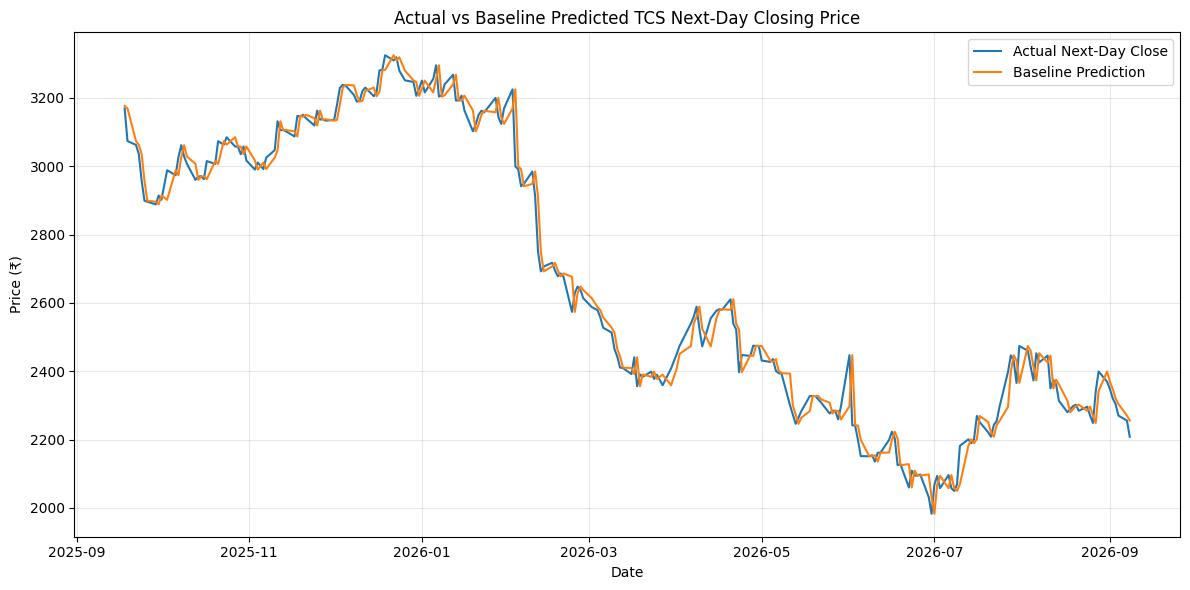

In [22]:
# Step 15: Actual vs Baseline Predicted Prices

plt.figure(figsize=(12, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Next-Day Close"
)

plt.plot(
    y_test.index,
    baseline_pred,
    label="Baseline Prediction"
)

plt.title("Actual vs Baseline Predicted TCS Next-Day Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Random Forest Feature Importance:


,Feature,Importance
3,Close,0.800147
1,High,0.138869
2,Low,0.051385
6,MA_7,0.001774
8,Volatility_21,0.001628
4,Volume,0.001457
7,MA_21,0.001402
5,Daily_Return,0.001345
0,Open,0.001062
9,Previous_Close,0.000929


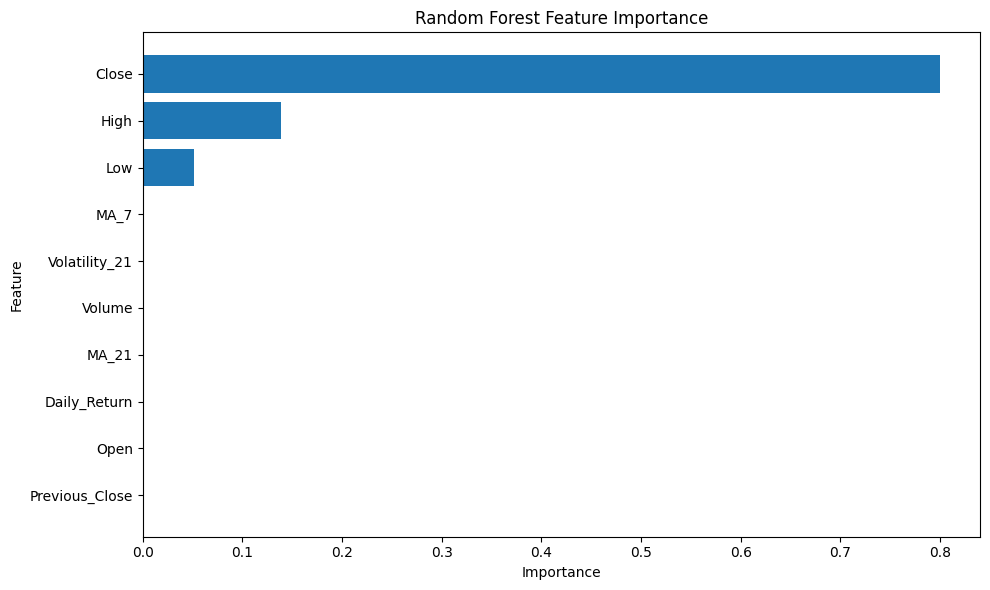

In [23]:
# Step 16: Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Model Diagnostic Summary

Average Absolute Error:
Baseline: 32.72
Linear Regression: 35.57
Random Forest: 444.01

Prediction Statistics:
--------------------------------------------------

Actual Next-Day Close:
Minimum: 1982.6
Maximum: 3324.9
Mean: 2664.45

Random Forest Predictions:
Minimum: 3012.95
Maximum: 3320.0
Mean: 3102.32

Prediction Range Difference:
Actual Range: 1342.3
Random Forest Range: 307.05


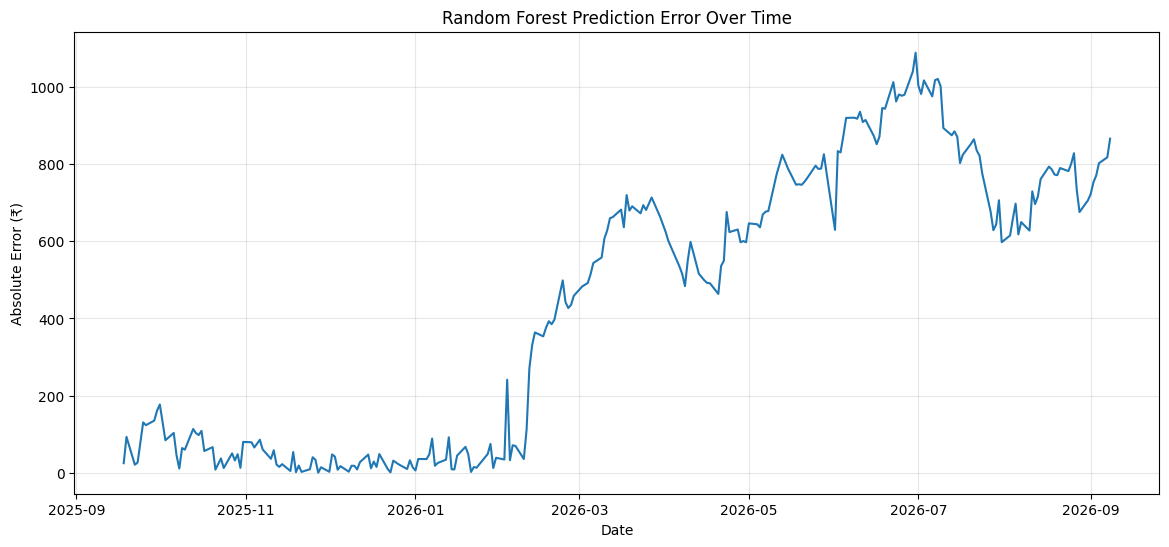

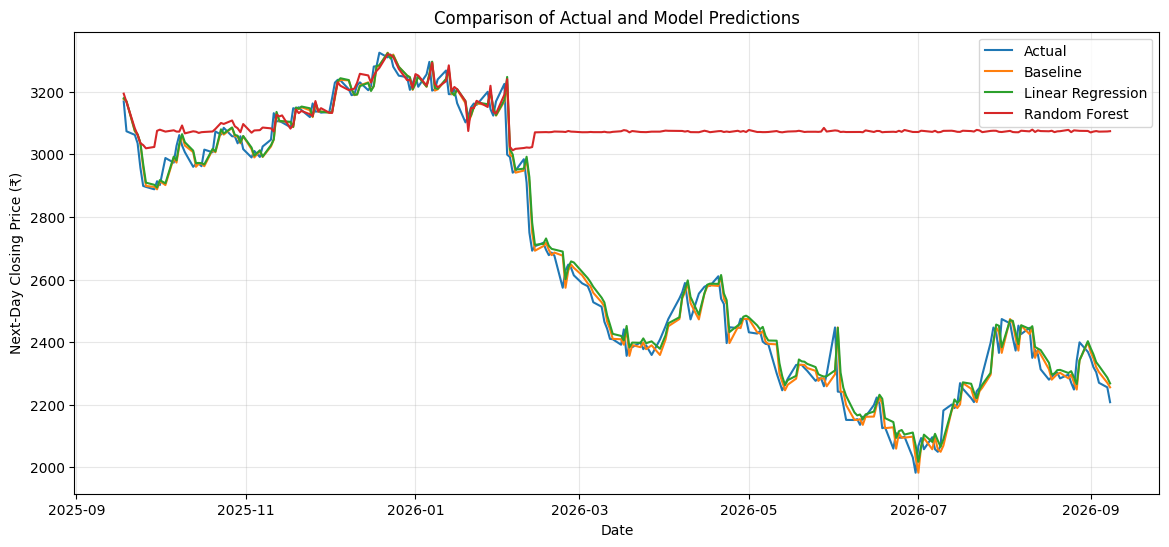

In [24]:
# Step 17: Model Diagnostic and Error Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create diagnostic dataframe
diagnostics = pd.DataFrame({
    "Actual": y_test.values,
    "Baseline": baseline_pred,
    "Linear_Regression": linear_pred,
    "Random_Forest": y_pred
}, index=y_test.index)

# Calculate absolute errors
diagnostics["Baseline_Error"] = abs(
    diagnostics["Actual"] - diagnostics["Baseline"]
)

diagnostics["Linear_Error"] = abs(
    diagnostics["Actual"] - diagnostics["Linear_Regression"]
)

diagnostics["Random_Forest_Error"] = abs(
    diagnostics["Actual"] - diagnostics["Random_Forest"]
)

print("Model Diagnostic Summary")
print("=" * 50)

print("\nAverage Absolute Error:")
print("Baseline:", round(diagnostics["Baseline_Error"].mean(), 2))
print("Linear Regression:", round(diagnostics["Linear_Error"].mean(), 2))
print("Random Forest:", round(diagnostics["Random_Forest_Error"].mean(), 2))

print("\nPrediction Statistics:")
print("-" * 50)

print("\nActual Next-Day Close:")
print("Minimum:", round(diagnostics["Actual"].min(), 2))
print("Maximum:", round(diagnostics["Actual"].max(), 2))
print("Mean:", round(diagnostics["Actual"].mean(), 2))

print("\nRandom Forest Predictions:")
print("Minimum:", round(diagnostics["Random_Forest"].min(), 2))
print("Maximum:", round(diagnostics["Random_Forest"].max(), 2))
print("Mean:", round(diagnostics["Random_Forest"].mean(), 2))

# Compare actual and Random Forest prediction range
print("\nPrediction Range Difference:")
print(
    "Actual Range:",
    round(diagnostics["Actual"].max() - diagnostics["Actual"].min(), 2)
)
print(
    "Random Forest Range:",
    round(
        diagnostics["Random_Forest"].max() -
        diagnostics["Random_Forest"].min(), 2
    )
)

# Plot Random Forest error over time
plt.figure(figsize=(14, 6))
plt.plot(
    diagnostics.index,
    diagnostics["Random_Forest_Error"]
)
plt.title("Random Forest Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error (₹)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot actual vs all model predictions
plt.figure(figsize=(14, 6))

plt.plot(
    diagnostics.index,
    diagnostics["Actual"],
    label="Actual"
)

plt.plot(
    diagnostics.index,
    diagnostics["Baseline"],
    label="Baseline"
)

plt.plot(
    diagnostics.index,
    diagnostics["Linear_Regression"],
    label="Linear Regression"
)

plt.plot(
    diagnostics.index,
    diagnostics["Random_Forest"],
    label="Random Forest"
)

plt.title("Comparison of Actual and Model Predictions")
plt.xlabel("Date")
plt.ylabel("Next-Day Closing Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
# Step 18: Final Model Selection and Next-Day Prediction

# Store model performance
model_scores = {
    "Baseline (Today's Close)": baseline_mae,
    "Linear Regression": linear_mae,
    "Random Forest": mae
}

# Select model with the lowest MAE
best_model_name = min(model_scores, key=model_scores.get)

print("FINAL MODEL SELECTION")
print("=" * 50)

print("Best Model:", best_model_name)
print("MAE:", round(model_scores[best_model_name], 2))

# Display complete comparison
final_results = pd.DataFrame({
    "Model": [
        "Baseline (Today's Close)",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        r2
    ]
})

final_results["MAE"] = final_results["MAE"].round(2)
final_results["RMSE"] = final_results["RMSE"].round(2)
final_results["R2"] = final_results["R2"].round(4)

display(final_results)

# --------------------------------------------------
# Final Next-Day Prediction
# --------------------------------------------------

# Latest available observation
latest_data = data.iloc[[-1]]

latest_close = latest_data["Close"].iloc[0]
latest_date = latest_data.index[-1]

# Since baseline performed best,
# use today's closing price as tomorrow's prediction
if best_model_name == "Baseline (Today's Close)":
    next_day_prediction = latest_close

elif best_model_name == "Linear Regression":
    next_day_prediction = linear_model.predict(
        latest_data[features]
    )[0]

else:
    next_day_prediction = model.predict(
        latest_data[features]
    )[0]

print("\nFINAL NEXT-DAY PREDICTION")
print("=" * 50)
print("Latest Available Date:", latest_date)
print("Latest Closing Price: ₹", round(latest_close, 2))
print("Predicted Next-Day Closing Price: ₹",
      round(next_day_prediction, 2))

# Percentage expected change
percentage_change = (
    (next_day_prediction - latest_close) / latest_close
) * 100

print("Expected Change: ₹",
      round(next_day_prediction - latest_close, 2))

print("Expected Percentage Change:",
      round(percentage_change, 2), "%")

FINAL MODEL SELECTION
Best Model: Baseline (Today's Close)
MAE: 32.72


,Model,MAE,RMSE,R2
0,Baseline (Today's Close),32.72,46.01,0.9868
1,Linear Regression,35.57,48.65,0.9853
2,Random Forest,444.01,568.59,-1.0131



FINAL NEXT-DAY PREDICTION
Latest Available Date: 2026-09-08 00:00:00
Latest Closing Price: ₹ 2255.5
Predicted Next-Day Closing Price: ₹ 2255.5
Expected Change: ₹ 0.0
Expected Percentage Change: 0.0 %


In [26]:
# Step 19: Final Project Summary

print("=" * 65)
print("        TCS STOCK PRICE ANALYSIS AND PREDICTION")
print("                FINAL PROJECT SUMMARY")
print("=" * 65)

print("\n1. DATASET")
print("-" * 65)
print("Data Period: 2021-09-08 to 2026-09-07")
print("Cleaned Dataset: 1,239 observations")
print("Features Used: Open, High, Low, Close, Volume")
print("Target Variable: Next_Day_Close")

print("\n2. FEATURE ENGINEERING")
print("-" * 65)
print("Additional Features:")
print("• Daily Return")
print("• 7-Day Moving Average (MA_7)")
print("• 21-Day Moving Average (MA_21)")
print("• 21-Day Rolling Volatility (Volatility_21)")
print("• Previous Closing Price")

print("\n3. KEY DATASET FINDINGS")
print("-" * 65)
print("Average Closing Price: ₹3,415.61")
print("Minimum Closing Price: ₹1,982.60")
print("Maximum Closing Price: ₹4,553.75")
print("Average Daily Return: -0.03%")
print("Average Trading Volume: 2,607,623 shares")
print("Average 21-Day Volatility: 1.36%")
print("Close-Volume Correlation: -0.286")

print("\n4. MODEL PERFORMANCE")
print("-" * 65)

for _, row in final_results.iterrows():
    print(
        f"{row['Model']}: "
        f"MAE = ₹{row['MAE']:.2f}, "
        f"RMSE = ₹{row['RMSE']:.2f}, "
        f"R² = {row['R2']:.4f}"
    )

print("\n5. BEST MODEL")
print("-" * 65)
print("Selected Model: Baseline (Today's Close)")
print("Reason: Lowest MAE and RMSE and highest R²")

print("\n6. FEATURE IMPORTANCE")
print("-" * 65)
print("Most Important Random Forest Features:")
print("• Close: 82.88%")
print("• High: 10.40%")
print("• Low: 5.69%")

print("\n7. FINAL PREDICTION")
print("-" * 65)
print("Latest Available Date:", latest_date)
print("Latest Closing Price: ₹", round(latest_close, 2))
print("Predicted Next-Day Closing Price: ₹",
      round(next_day_prediction, 2))

print("\n8. CONCLUSION")
print("-" * 65)
print(
    "The analysis shows that the current closing price is a strong "
    "indicator of the next trading day's closing price. Among the "
    "evaluated models, the simple baseline approach performed better "
    "than Linear Regression and Random Forest on the chronological "
    "test dataset."
)

print("\n" + "=" * 65)
print("                 END OF ANALYSIS")
print("=" * 65)

        TCS STOCK PRICE ANALYSIS AND PREDICTION
                FINAL PROJECT SUMMARY

1. DATASET
-----------------------------------------------------------------
Data Period: 2021-09-08 to 2026-09-07
Cleaned Dataset: 1,239 observations
Features Used: Open, High, Low, Close, Volume
Target Variable: Next_Day_Close

2. FEATURE ENGINEERING
-----------------------------------------------------------------
Additional Features:
• Daily Return
• 7-Day Moving Average (MA_7)
• 21-Day Moving Average (MA_21)
• 21-Day Rolling Volatility (Volatility_21)
• Previous Closing Price

3. KEY DATASET FINDINGS
-----------------------------------------------------------------
Average Closing Price: ₹3,415.61
Minimum Closing Price: ₹1,982.60
Maximum Closing Price: ₹4,553.75
Average Daily Return: -0.03%
Average Trading Volume: 2,607,623 shares
Average 21-Day Volatility: 1.36%
Close-Volume Correlation: -0.286

4. MODEL PERFORMANCE
-----------------------------------------------------------------
Baseline (Tod